In [4]:
import pandas as pd
jobsalary_df = pd.read_csv('../data/job_salary_prediction_dataset.csv')

jobsalary_df.describe()
jobsalary_df.info()
jobsalary_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
from functools import partial
get_ipython().showtraceback = partial(get_ipython().showtraceback, exception_only=True)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 'salary' is target
X = jobsalary_df.drop('salary', axis=1)
y = jobsalary_df['salary']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model (This might fail if you have NaNs or non-numeric data)
model = LinearRegression()
model.fit(X_train, y_train)

# results
y_pred = model.predict(X_test)
print(f"Initial R square: {r2_score(y_test, y_pred)}")

ValueError: could not convert string to float: 'Machine Learning Engineer'

In [7]:
print(jobsalary_df['job_title'].value_counts())
print(jobsalary_df['industry'].value_counts())
print(jobsalary_df['location'].value_counts())
print(jobsalary_df['remote_work'].value_counts())
print(jobsalary_df['company_size'].value_counts())
print(jobsalary_df['education_level'].value_counts())

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64
remote_work
No        83621
Hybrid

In [8]:
# transforming and traning
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.metrics import r2_score

# Ordinal Order
degree_order = [['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']]

# column transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(target_type='continuous'), ['job_title', 'industry', 'location']),
        ('ohe', OneHotEncoder(drop='first'), ['company_size', 'remote_work']),
        ('order', OrdinalEncoder(categories=degree_order), ['education_level'])
    ],
    remainder='passthrough'
)

# bundles the preprocessing AND the model together
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# data spliting for traning and testing
X = jobsalary_df.drop('salary', axis=1)
y = jobsalary_df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fits all encoders AND the model correctly
model_pipeline.fit(X_train, y_train)

# Predict
# the pipeline handles the encoding internally
y_pred = model_pipeline.predict(X_test)
#print(f"Predictions: {predictions}")

# R-squared
r2 = r2_score(y_test, y_pred)

# Adjusted R-squared
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

R2 Score: 0.9603
Adjusted R2: 0.9603


In [9]:
# Extract feature names and coefficients
features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
coeffs = model_pipeline.named_steps['regressor'].coef_

# Create a 'Drivers' table
drivers = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
drivers['Abs_Influence'] = drivers['Coefficient'].abs()
drivers = drivers.sort_values(by='Abs_Influence', ascending=False)

print(drivers.head(10))

                        Feature   Coefficient  Abs_Influence
6     ohe__company_size_Startup -42402.603783   42402.603783
5       ohe__company_size_Small -35401.646410   35401.646410
4      ohe__company_size_Medium -28289.425759   28289.425759
3       ohe__company_size_Large -14146.706401   14146.706401
9        order__education_level   8069.531967    8069.531967
8          ohe__remote_work_Yes   5333.101052    5333.101052
10  remainder__experience_years   2698.207808    2698.207808
12    remainder__certifications   1610.518212    1610.518212
11      remainder__skills_count    856.581417     856.581417
7           ohe__remote_work_No     -6.733554       6.733554


In [10]:
# cross vaiidation score
from sklearn.model_selection import cross_val_score

# Use the whole pipeline
scores = cross_val_score(model_pipeline, X, y, cv=5)
print(f"Average CV R2: {scores.mean():.2f}")

Average CV R2: 0.96


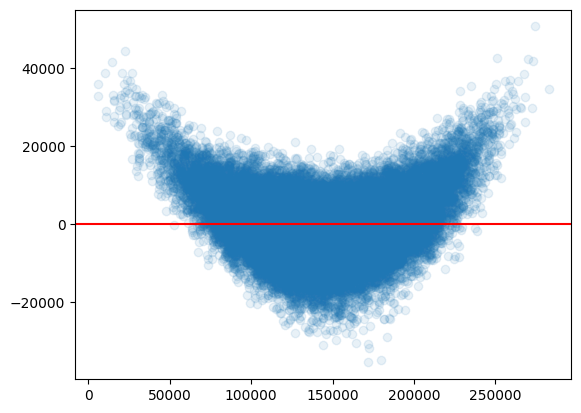

In [11]:
# residual plot
import matplotlib.pyplot as plt
#y_pred = model_pipeline.predict(X_test)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.1) # alpha helps see density in 50k points
plt.axhline(0, color='red')
plt.show()

R2 Score: 0.9709
Adjusted R2: 0.9709


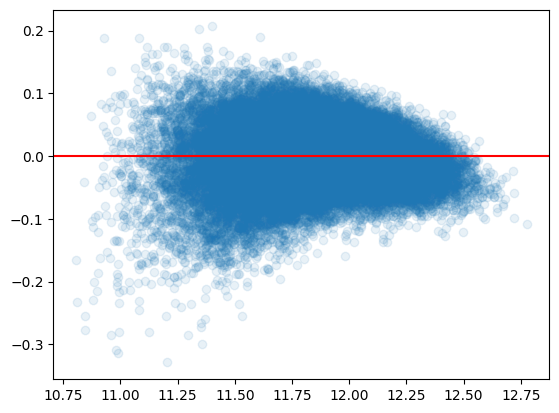

In [13]:
import numpy as np

# fits all encoders AND the model correctly
# note: this time we do salary log transformation
y_train_log = np.log1p(y_train)
model_pipeline.fit(X_train, y_train_log)

# Predict
# the pipeline handles the encoding internally
y_pred = model_pipeline.predict(X_test)
#print(f"Predictions: {predictions}")

# also need to transform test data into log
y_test_log = np.log1p(y_test)
# R-squared
r2 = r2_score(y_test_log, y_pred)

# Adjusted R-squared
n = len(y_test_log)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

# residual plot 
residuals = y_test_log - y_pred
plt.scatter(y_pred, residuals, alpha=0.1) # alpha helps see density in 50k points
plt.axhline(0, color='red')
plt.show()

R2 Score: 0.9712
Adjusted R2: 0.9712


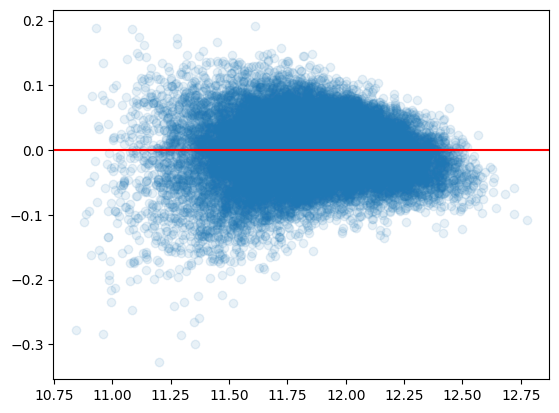

In [14]:
# note: this time we will go with 90:10 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# fits all encoders AND the model correctly
# note: this time we do salary log transformation
y_train_log = np.log1p(y_train)
model_pipeline.fit(X_train, y_train_log)

# Predict
# the pipeline handles the encoding internally
y_pred = model_pipeline.predict(X_test)
#print(f"Predictions: {predictions}")

# also need to transform test data into log
y_test_log = np.log1p(y_test)
# R-squared
r2 = r2_score(y_test_log, y_pred)

# Adjusted R-squared
n = len(y_test_log)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

# residual plot 
residuals = y_test_log - y_pred
plt.scatter(y_pred, residuals, alpha=0.1) # alpha helps see density in 50k points
plt.axhline(0, color='red')
plt.show()

In [15]:
# Extract feature names and coefficients
features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
coeffs = model_pipeline.named_steps['regressor'].coef_

# Create a 'Drivers' table
drivers = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
drivers['Abs_Influence'] = drivers['Coefficient'].abs()
drivers = drivers.sort_values(by='Abs_Influence', ascending=False)

print(drivers.head(10))

                        Feature  Coefficient  Abs_Influence
0             target__job_title     1.004616       1.004616
2              target__location     0.999714       0.999714
6     ohe__company_size_Startup    -0.287488       0.287488
5       ohe__company_size_Small    -0.233673       0.233673
4      ohe__company_size_Medium    -0.182208       0.182208
3       ohe__company_size_Large    -0.087022       0.087022
1              target__industry    -0.070295       0.070295
9        order__education_level     0.056415       0.056415
8          ohe__remote_work_Yes     0.037923       0.037923
10  remainder__experience_years     0.019035       0.019035


In [17]:
import statsmodels.api as sm

# note: this time we will compute p values
# Transform your Training Data using the pipeline's preprocessor
# This handles your TargetEncoding, OneHot, and Ordinal steps
X_train_transformed = model_pipeline.named_steps['preprocessor'].transform(X_train)

# Get the actual feature names (so the table is readable)
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Convert to a DataFrame for statsmodels
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)

# Add the 'Intercept' (statsmodels doesn't add it automatically)
X_train_final = sm.add_constant(X_train_final)

# Log-transform your target (since your model uses log(y))
# Reset the index of X_train_final and y_train_log to match
y_train_log = np.log1p(y_train).reset_index(drop=True)
X_train_final = X_train_final.reset_index(drop=True)

# Fit the Ordinary Least Squares (OLS) model
sm_model = sm.OLS(y_train_log, X_train_final).fit()

# Print the beautiful summary table
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 5.764e+05
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:13:30   Log-Likelihood:             3.7697e+05
No. Observations:              225000   AIC:                        -7.539e+05
Df Residuals:                  224986   BIC:                        -7.538e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

R2 Score: 0.9712
Adjusted R2: 0.9712


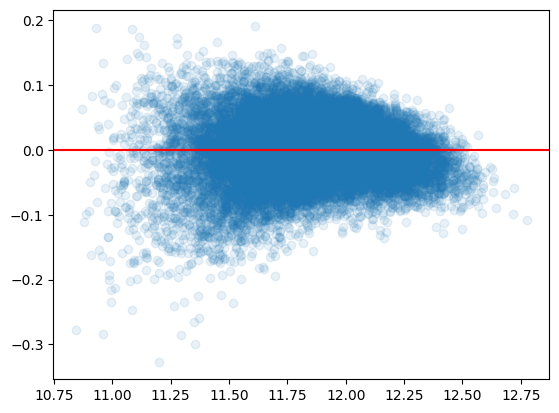

                        Feature  Coefficient  Abs_Influence
0             target__job_title     1.004580       1.004580
1              target__location     0.999693       0.999693
5     ohe__company_size_Startup    -0.287492       0.287492
4       ohe__company_size_Small    -0.233686       0.233686
3      ohe__company_size_Medium    -0.182197       0.182197
2       ohe__company_size_Large    -0.087020       0.087020
8        order__education_level     0.056412       0.056412
7          ohe__remote_work_Yes     0.037928       0.037928
9   remainder__experience_years     0.019035       0.019035
11    remainder__certifications     0.011490       0.011490


In [19]:
# NOTE: now we will drop a column (industry) which is not a great predictor
# column transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(target_type='continuous'), ['job_title', 'location']),
        ('ohe', OneHotEncoder(drop='first'), ['company_size', 'remote_work']),
        ('order', OrdinalEncoder(categories=degree_order), ['education_level'])
    ],
    remainder='passthrough'
)

# bundles the preprocessing AND the model together
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# NOTE THIS: here I am modifying dataframe to prepare dataset
# data spliting for traning and testing
X = jobsalary_df.drop(['salary', 'industry'], axis=1)
y = jobsalary_df['salary']
# 90: 10 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# fits all encoders AND the model correctly
# note: this time we do salary log transformation
y_train_log = np.log1p(y_train)
model_pipeline.fit(X_train, y_train_log)

# Predict
# the pipeline handles the encoding internally
y_pred = model_pipeline.predict(X_test)
#print(f"Predictions: {predictions}")

# also need to transform test data into log
y_test_log = np.log1p(y_test)
# R-squared
r2 = r2_score(y_test_log, y_pred)

# Adjusted R-squared
n = len(y_test_log)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

# residual plot 
residuals = y_test_log - y_pred
plt.scatter(y_pred, residuals, alpha=0.1) # alpha helps see density in 50k points
plt.axhline(0, color='red')
plt.show()

# Extract feature names and coefficients
features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
coeffs = model_pipeline.named_steps['regressor'].coef_

# Create a 'Drivers' table
drivers = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
drivers['Abs_Influence'] = drivers['Coefficient'].abs()
drivers = drivers.sort_values(by='Abs_Influence', ascending=False)

print(drivers.head(10))

R2 Score: 0.9711
Adjusted R2: 0.9711


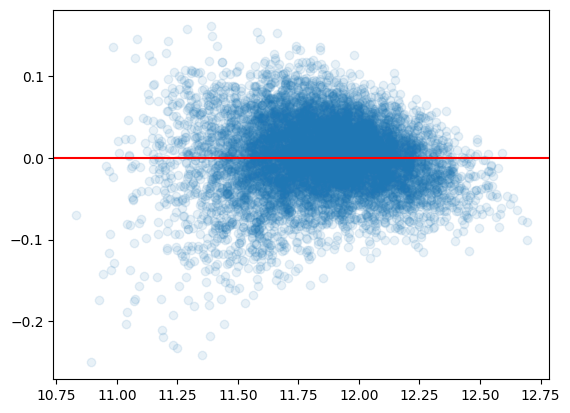

                       Feature  Coefficient  Abs_Influence
0            target__job_title     0.991936       0.991936
1             target__location     0.989251       0.989251
5    ohe__company_size_Startup    -0.287232       0.287232
4      ohe__company_size_Small    -0.233818       0.233818
3     ohe__company_size_Medium    -0.182096       0.182096
2      ohe__company_size_Large    -0.087262       0.087262
6       order__education_level     0.057287       0.057287
7  remainder__experience_years     0.019311       0.019311
9    remainder__certifications     0.011726       0.011726
8      remainder__skills_count     0.006258       0.006258


In [21]:
# NOTE THIS: here I am modifying dataframe to prepare dataset
# also now deletitng no remote work no

# data spliting for traning and testing
cleaned_jobsalary_df = jobsalary_df[jobsalary_df['remote_work'] == 'No']
X = cleaned_jobsalary_df.drop(['salary', 'industry'], axis=1)
y = cleaned_jobsalary_df['salary']
# 90: 10 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# fits all encoders AND the model correctly
# note: this time we do salary log transformation
y_train_log = np.log1p(y_train)
model_pipeline.fit(X_train, y_train_log)

# Predict
# the pipeline handles the encoding internally
y_pred = model_pipeline.predict(X_test)
#print(f"Predictions: {predictions}")

# also need to transform test data into log
y_test_log = np.log1p(y_test)
# R-squared
r2 = r2_score(y_test_log, y_pred)

# Adjusted R-squared
n = len(y_test_log)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

# residual plot 
residuals = y_test_log - y_pred
plt.scatter(y_pred, residuals, alpha=0.1) # alpha helps see density in 50k points
plt.axhline(0, color='red')
plt.show()

# Extract feature names and coefficients
features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
coeffs = model_pipeline.named_steps['regressor'].coef_

# Create a 'Drivers' table
drivers = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
drivers['Abs_Influence'] = drivers['Coefficient'].abs()
drivers = drivers.sort_values(by='Abs_Influence', ascending=False)

print(drivers.head(10))